# Data retrieval

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
eed_df = pd.read_excel(r'energy efficiency detection webapp/ENB2012_data.xlsx')
eed_df

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [5]:
eed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [6]:
eed_df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


# Data cleaning

## Duplicates

In [7]:
eed_df.duplicated().sum()

np.int64(0)

## Missing values

In [8]:
eed_df.isna().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

## Outliers

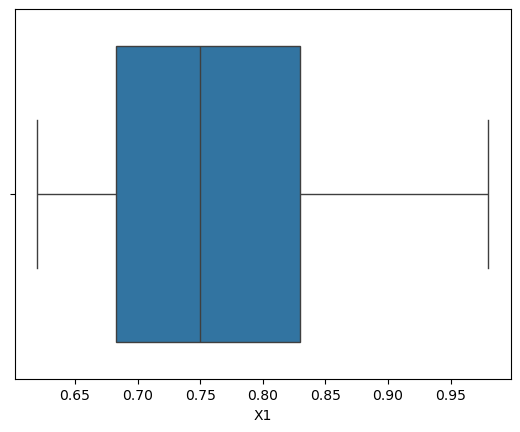

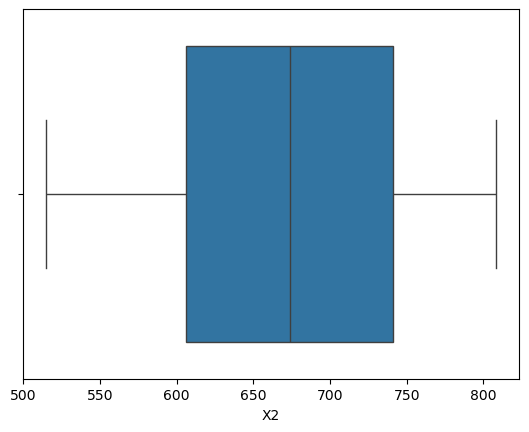

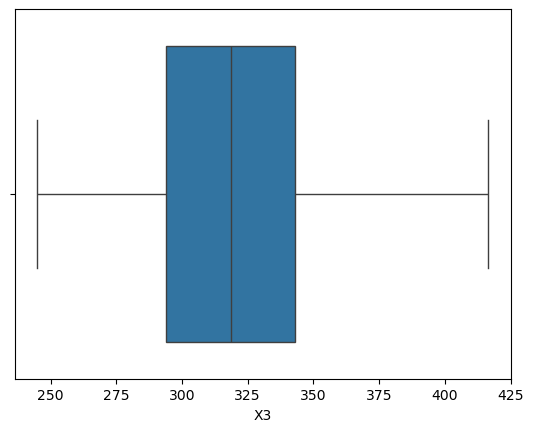

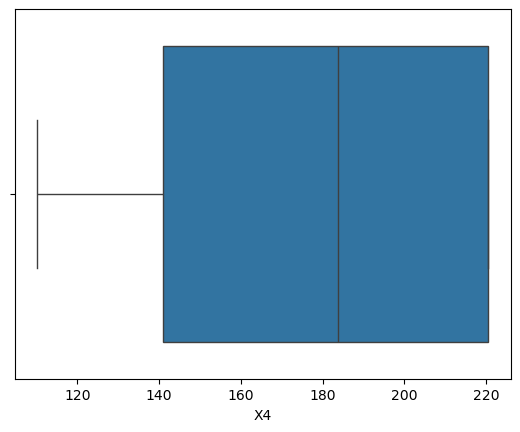

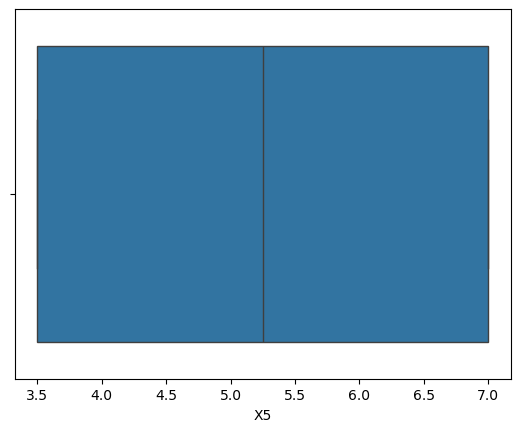

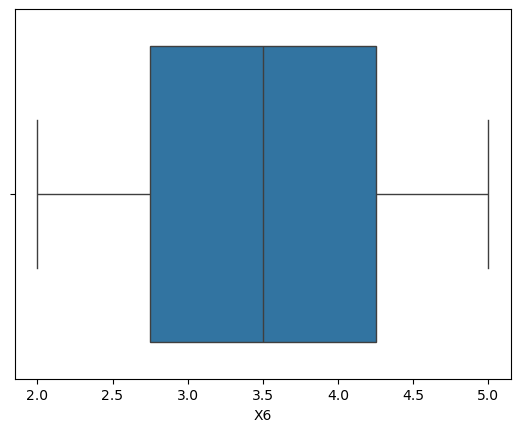

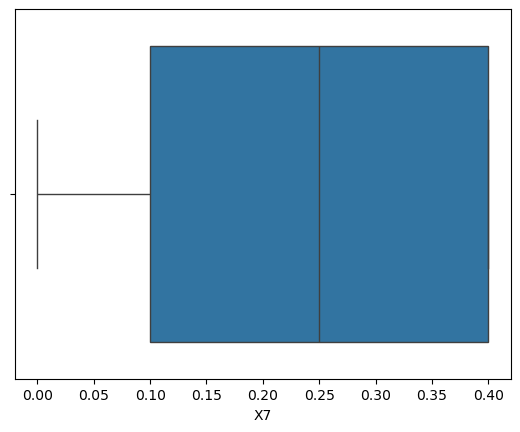

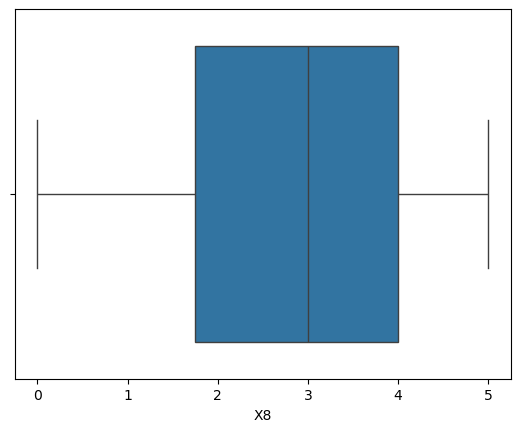

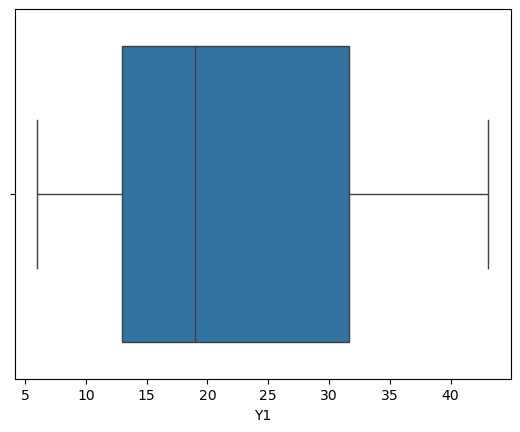

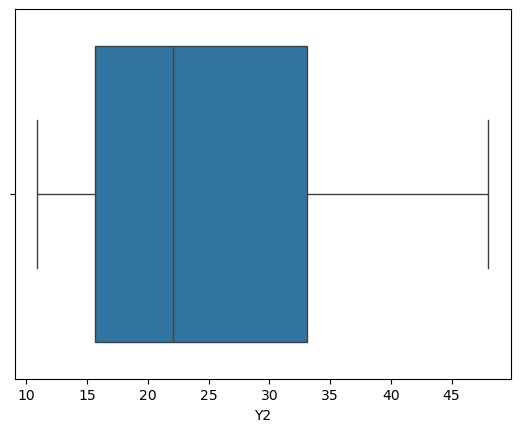

In [9]:
# All columns are numerical
cols = eed_df.columns

for col in cols:
    plt.figure()
    sns.boxplot(eed_df[col], orient='h')
    plt.show()

# Data preprocessing

## Standardization

In [10]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
model_inputs = eed_df.drop(['Y1','Y2'], axis=1).columns

eed_df[model_inputs] = ss.fit_transform(eed_df[model_inputs])
eed_df

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,2.041777,-1.785875,-0.561951,-1.470077,1.0,-1.341641,-1.760447,-1.814575,15.55,21.33
1,2.041777,-1.785875,-0.561951,-1.470077,1.0,-0.447214,-1.760447,-1.814575,15.55,21.33
2,2.041777,-1.785875,-0.561951,-1.470077,1.0,0.447214,-1.760447,-1.814575,15.55,21.33
3,2.041777,-1.785875,-0.561951,-1.470077,1.0,1.341641,-1.760447,-1.814575,15.55,21.33
4,1.284979,-1.229239,0.000000,-1.198678,1.0,-1.341641,-1.760447,-1.814575,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,-1.174613,1.275625,0.561951,0.972512,-1.0,1.341641,1.244049,1.411336,17.88,21.40
764,-1.363812,1.553943,1.123903,0.972512,-1.0,-1.341641,1.244049,1.411336,16.54,16.88
765,-1.363812,1.553943,1.123903,0.972512,-1.0,-0.447214,1.244049,1.411336,16.44,17.11
766,-1.363812,1.553943,1.123903,0.972512,-1.0,0.447214,1.244049,1.411336,16.48,16.61


## Data splitting

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
y = eed_df[["Y1","Y2"]]
X = eed_df.drop(["Y1","Y2"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Model building

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr_model_two = LinearRegression()
lr_model_two.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Evaluation

In [15]:
y_pred = lr_model_two.predict(X_test)

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error

In [17]:
r2 = r2_score(y_test, y_pred)
r2

0.9035990988701139

In [18]:
mae = mean_absolute_error(y_test, y_pred)
mae

2.2110408188717363

In [19]:
rmse = root_mean_squared_error(y_test, y_pred)
rmse

3.0811409400543046

In [20]:
mse = mean_squared_error(y_test, y_pred)
mse

9.501125731822928

In [21]:
# Rule of thumb check 
rmse > 0.2 * y.max()

Y1    False
Y2    False
dtype: bool

## Test

In [22]:
X_test

,X1,X2,X3,X4,X5,X6,X7,X8
668,-1.363812,1.553943,1.123903,0.972512,-1.0,-1.341641,1.244049,0.120972
324,-0.985413,0.997307,0.000000,0.972512,-1.0,-1.341641,0.117363,-1.169393
624,2.041777,-1.785875,-0.561951,-1.470077,1.0,-1.341641,1.244049,0.120972
690,0.244383,-0.394284,0.561951,-0.655880,1.0,0.447214,1.244049,0.766154
473,-1.174613,1.275625,0.561951,0.972512,-1.0,-0.447214,0.117363,0.766154
...,...,...,...,...,...,...,...,...
554,-0.228616,0.162352,-1.685854,0.972512,-1.0,0.447214,1.244049,-1.169393
319,-0.512415,0.440670,-1.123903,0.972512,-1.0,1.341641,0.117363,-1.169393
594,0.244383,-0.394284,0.561951,-0.655880,1.0,0.447214,1.244049,-0.524211
6,1.284979,-1.229239,0.000000,-1.198678,1.0,0.447214,-1.760447,-1.814575


In [23]:
# Create test
my_test = pd.DataFrame({
    'X1': [0.62,0.92,0.77,0.75,0.98],
    'X2': [515,808,600,516.35,700.5],
    'X3': [248,400.5,300.4,298.65,310.5],
    'X4': [112.5,150.5,200.5,199.98,210.5],
    'X5': [3.6,4.0,5.0,6.0,6.8],
    'X6': [2,3,5,4,2],
    'X7': [0.0,0.1,0.35,0.4,0.22],
    'X8': [4,5,1,2,3]
})
my_test

,X1,X2,X3,X4,X5,X6,X7,X8
0,0.62,515.00,248.00,112.50,3.6,2,0.00,4
1,0.92,808.00,400.50,150.50,4.0,3,0.10,5
2,0.77,600.00,300.40,200.50,5.0,5,0.35,1
3,0.75,516.35,298.65,199.98,6.0,4,0.40,2
4,0.98,700.50,310.50,210.50,6.8,2,0.22,3


In [24]:
# Continuous cols
my_test_num_cols = my_test.columns

my_test = ss.transform(my_test).round(2)

my_test = pd.DataFrame(my_test, columns=my_test_num_cols)

my_test

,X1,X2,X3,X4,X5,X6,X7,X8
0,-1.36,-1.78,-1.62,-1.42,-0.94,-1.34,-1.76,0.77
1,1.47,1.55,1.88,-0.58,-0.71,-0.45,-1.01,1.41
2,0.06,-0.81,-0.42,0.53,-0.14,1.34,0.87,-1.17
3,-0.13,-1.76,-0.46,0.52,0.43,0.45,1.24,-0.52
4,2.04,0.33,-0.18,0.75,0.89,-1.34,-0.11,0.12


In [25]:
res = lr_model_two.predict(my_test)

In [27]:
res = pd.DataFrame(res, columns=['Y1','Y2'])

In [30]:
res.head(5).reset_index(names="Design")

,Design,Y1,Y2
0,0,32.071522,38.922357
1,1,3.031520,2.091884
2,2,23.187560,25.835014
3,3,33.413696,36.210670
4,4,9.883619,9.758069


## Pairwise heatmap

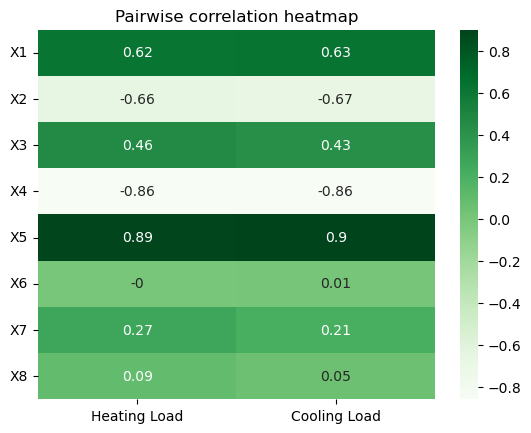

In [31]:
corr_mx = eed_df.corr()
corr_mx = corr_mx.round(2)
# Select irrelevant cols
rel_cols = ['Y1','Y2']
corr_mx = corr_mx.loc['X1':'X8',rel_cols]
sns.heatmap(corr_mx, cmap='Greens', annot=True)
plt.title('Pairwise correlation heatmap')
plt.yticks(rotation=0)
plt.xticks([0.5,1.5], ['Heating Load','Cooling Load'])
plt.show()

In [32]:
corr_mx

,Y1,Y2
X1,0.62,0.63
X2,-0.66,-0.67
X3,0.46,0.43
X4,-0.86,-0.86
X5,0.89,0.90
X6,-0.00,0.01
X7,0.27,0.21
X8,0.09,0.05


## Exporting the model

In [26]:
import joblib

In [27]:
joblib.dump((ss, lr_model_two), 'eed.pkl')

['eed.pkl']